In [1]:
import pandas as pd
import os
from glob import glob
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import CategoricalAccuracy
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Data Preprocessing

In [ ]:
#read the data from the balanced files (Oversampled) from the local directory
directory = "D:\\ICSE_Dataset\\CSV_Balanced_CorrectBuggy_Oversampled"

data_points = []
def convert_tensor_to_bool(tensor_str):
    if isinstance(tensor_str, str):
        return 'True' in tensor_str
    elif isinstance(tensor_str, bool):
        return tensor_str
    elif isinstance(tensor_str, int):
        return bool(tensor_str)
    return False

columns_to_delete = ['loss_oscillation', 'decrease_acc_count', 'increase_loss_count', 'cons_mean_weight_count', 'cons_std_weight_count']
for filename in os.listdir(directory):
    if filename.endswith('.csv'):
        label = 'buggy' if 'buggy' in filename else 'correct'
        file_path = os.path.join(directory, filename)
        df = pd.read_csv(file_path)
        if 'dying_relu' in df.columns:
            df['dying_relu'] = df['dying_relu'].apply(lambda x: convert_tensor_to_bool(x))
        df = df.drop(columns=columns_to_delete, errors='ignore')
        data_point = df.mean().to_frame().T
        data_point['label'] = label
        data_points.append(data_point)

df_combined = pd.concat(data_points, ignore_index=True)
print(df_combined.head())

In [3]:
data = df_combined.copy()
data.to_csv('D:\\ICSE_Dataset\\1st_Level_OverSampled.csv', index=False)

,epoch,train_loss,train_acc,val_loss,val_acc,large_weight_count,acc_gap_too_big,dying_relu,gradient_vanish,gradient_explode,...,gradient_median,adjusted_lr,mean_activation,std_activation,mean_grad,std_grad,cpu_utilization,gpu_memory_utilization,memory_usage,label
0,24.5,0.092246,-2.650498,0.095944,-1.689159,0.0,1.00,1.00,0.78,0.0,...,0.002688,0.000179,0.367428,0.276954,-0.000626,0.002607,4.762,65.174683,12.830,buggy
1,24.5,0.113146,-2.412433,0.116135,-1.936848,0.0,0.96,1.00,0.88,0.0,...,0.002119,0.000179,0.226975,0.144448,-0.002393,0.003390,4.516,66.019556,14.994,buggy
2,24.5,0.111131,-2.344579,0.109154,-4.260542,0.0,0.96,1.00,0.90,0.0,...,0.001594,0.000179,0.242968,0.167864,-0.002144,0.003311,16.694,66.781040,17.720,buggy
3,24.5,0.691411,0.061800,0.694048,0.000000,0.0,0.10,0.00,1.00,0.0,...,0.016728,0.000179,0.178879,0.023772,0.000196,0.001322,2.140,201.555420,7.400,buggy
4,24.5,0.692302,0.334847,0.694626,0.337800,0.0,0.00,0.00,1.00,0.0,...,0.000664,0.000179,0.086455,0.039288,-0.000133,0.000651,3.072,56.423555,8.900,correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12409,24.5,0.138888,-4.038404,0.133181,-22.187726,0.0,1.00,1.00,0.98,0.0,...,0.000011,0.000179,0.142539,0.001109,-0.004346,0.000807,4.674,63.536494,11.332,buggy
12410,24.5,0.092805,-15.636083,0.095638,-8.599579,0.0,1.00,1.00,0.90,0.0,...,0.002146,0.000179,0.289855,0.209445,-0.001037,0.003199,3.986,64.511919,10.992,buggy
12411,24.5,0.021345,0.992907,0.016896,1.000000,0.0,0.02,0.04,0.98,0.0,...,0.010335,0.001791,0.352025,2.419147,-0.000230,0.001613,3.694,4198.474390,7.900,correct
12412,24.5,2.302381,0.102310,2.302871,0.101400,0.0,0.00,1.00,1.00,0.0,...,0.000022,0.000179,0.020088,0.000844,0.000003,0.003351,3.400,376.268311,8.958,buggy


In [46]:
#read the data from the balanced files (Undersampled) from the local directory
directory = "D:\\ICSE_Dataset\\CSV_Balanced_CorrectBuggy_Undersampled"

data_points = []
def convert_tensor_to_bool(tensor_str):
    if isinstance(tensor_str, str):
        return 'True' in tensor_str
    elif isinstance(tensor_str, bool):
        return tensor_str
    elif isinstance(tensor_str, int):
        return bool(tensor_str)
    return False

columns_to_delete = ['loss_oscillation', 'decrease_acc_count', 'increase_loss_count', 'cons_mean_weight_count', 'cons_std_weight_count']
for filename in os.listdir(directory):
    if filename.endswith('.csv'):
        label = 'buggy' if 'buggy' in filename else 'correct'
        file_path = os.path.join(directory, filename)
        df = pd.read_csv(file_path)
        if 'dying_relu' in df.columns:
            df['dying_relu'] = df['dying_relu'].apply(lambda x: convert_tensor_to_bool(x))
        df = df.drop(columns=columns_to_delete, errors='ignore')
        data_point = df.mean().to_frame().T
        data_point['label'] = label
        data_points.append(data_point)

df_combined = pd.concat(data_points, ignore_index=True)
print(df_combined.head())

data = df_combined.copy()
data.to_csv('D:\\ICSE_Dataset\\1st_Level_UnderSampled.csv', index=False)

C:\Users\sigma\AppData\Local\Temp\ipykernel_25572\2959371662.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_combined = pd.concat(data_points, ignore_index=True)


   epoch  train_loss  train_acc  val_loss  val_acc  large_weight_count  \
0   24.5    0.097683        NaN  0.172780      NaN                 0.0   
1   24.5    0.690644   0.362644  0.696144   0.2924                 0.0   
2   24.5    0.065116        NaN  0.155887      NaN                 0.0   
3   24.5    0.072352        NaN  0.203196      NaN                 0.0   
4   24.5    0.691527   0.356881  0.694571   0.3500                 0.0   

   acc_gap_too_big  dying_relu  gradient_vanish  gradient_explode  ...  \
0              0.0         0.0             0.00               0.0  ...   
1              0.1         0.0             1.00               0.0  ...   
2              0.0         0.0             0.16               0.0  ...   
3              0.0         0.0             0.02               0.0  ...   
4              0.0         0.0             1.00               0.0  ...   

   gradient_median  adjusted_lr  mean_activation  std_activation  mean_grad  \
0         0.028082     0.000179

Start from here if you have the CSV file for the combined dataframe - named as 1st_level_Oversampled/1st_level_Undersampled

In [48]:
# read the data from the csv file in this directory
df_combined = pd.read_csv('C:\\Users\\sigma\Documents\\GitHub\\ASE_2024\\c_binary_classifiers\\1st_Level_UnderSampled.csv')

In [49]:
df_combined = pd.concat(data_points, ignore_index=True)

C:\Users\sigma\AppData\Local\Temp\ipykernel_25572\18396798.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_combined = pd.concat(data_points, ignore_index=True)


In [50]:
X = df_combined.drop(columns=['label'])
y = df_combined['label']

In [51]:
X = X.apply(lambda x: x.fillna(x.mean()), axis=0)

In [52]:
X = X.replace([np.inf, -np.inf], np.nan).apply(lambda x: x.fillna(x.max()), axis=0)

In [53]:
for column in X.columns:
    if X[column].isna().sum() > 0 or np.isinf(X[column]).sum() > 0:
        X[column] = X[column].replace([np.inf, -np.inf], np.nan).fillna(X[column].mean())
    lower_quantile = X[column].quantile(0.01)
    upper_quantile = X[column].quantile(0.99)

    X[column] = X[column].clip(lower=lower_quantile, upper=upper_quantile)

In [54]:
X = X.apply(lambda x: x.fillna(x.mean()), axis=0)
X = X.replace([np.inf, -np.inf], np.nan).apply(lambda x: x.fillna(x.mean()), axis=0)

In [55]:
if X.isna().sum().sum() > 0 or np.isinf(X).sum().sum() > 0:
    print("There are still NaNs or infinite values in the DataFrame. Additional cleaning needed.")
else:
    print("Data cleaning completed successfully. No NaNs or infinite values remain.")

Data cleaning completed successfully. No NaNs or infinite values remain.


In [56]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [57]:
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.values.reshape(-1, 1))

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

In [59]:
print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)


X_train shape:  (7670, 26)
X_test shape:  (1918, 26)
y_train shape:  (7670, 2)
y_test shape:  (1918, 2)


In [60]:
X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

Robin Bhaia's Model

In [61]:
def build_model(input_shape, num_classes):
    input_layer = Input(shape=input_shape, name='input')

    conv1 = Conv1D(32, kernel_size=(3,), activation='relu', kernel_regularizer=l2(0.01), name='conv1')(input_layer)
    conv2 = Conv1D(64, kernel_size=(3,), activation='relu', kernel_regularizer=l2(0.01), name='conv2')(conv1)
    pool1 = MaxPooling1D(pool_size=(2,), name='pool1')(conv2)
    flatten = Flatten(name='flatten')(pool1)
    dense1 = Dense(128, activation='relu', kernel_regularizer=l2(0.01), name='dense')(flatten)
    output_layer = Dense(num_classes, activation='softmax', name='output')(dense1)

    model = Model(input_layer, output_layer, name='static_model')
    model.compile(
        loss=CategoricalCrossentropy(),
        optimizer=Adam(learning_rate=1e-3),
        metrics=[CategoricalAccuracy(name="acc")],
    )

    return model

model = build_model(input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]), num_classes=y_encoded.shape[1])
model.summary()

Model: "static_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 26, 1)]           0         
                                                                 
 conv1 (Conv1D)              (None, 24, 32)            128       
                                                                 
 conv2 (Conv1D)              (None, 22, 64)            6208      
                                                                 
 pool1 (MaxPooling1D)        (None, 11, 64)            0         
                                                                 
 flatten (Flatten)           (None, 704)               0         
                                                                 
 dense (Dense)               (None, 128)               90240     
                                                                 
 output (Dense)              (None, 2)                

In [62]:
early_stopping = EarlyStopping(monitor='val_acc', patience=5)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    verbose=1,
    validation_data=(X_train, y_train),
    callbacks=[early_stopping],
)

if not os.path.exists('../models'):
    os.makedirs('../models')

model.save('../models/static_model.keras')

Epoch 1/100
240/240 [==============================] - 2s 5ms/step - loss: 1.0634 - acc: 0.6095 - val_loss: 0.6603 - val_acc: 0.6343
Epoch 2/100
240/240 [==============================] - 1s 4ms/step - loss: 0.6510 - acc: 0.6368 - val_loss: 0.6334 - val_acc: 0.6451
Epoch 3/100
240/240 [==============================] - 1s 4ms/step - loss: 0.6302 - acc: 0.6722 - val_loss: 0.6236 - val_acc: 0.6681
Epoch 4/100
240/240 [==============================] - 1s 4ms/step - loss: 0.6212 - acc: 0.6803 - val_loss: 0.6160 - val_acc: 0.6815
Epoch 5/100
240/240 [==============================] - 1s 4ms/step - loss: 0.6141 - acc: 0.6871 - val_loss: 0.6158 - val_acc: 0.6892
Epoch 6/100
240/240 [==============================] - 1s 4ms/step - loss: 0.6064 - acc: 0.6889 - val_loss: 0.6048 - val_acc: 0.6974
Epoch 7/100
240/240 [==============================] - 1s 4ms/step - loss: 0.6071 - acc: 0.6906 - val_loss: 0.5973 - val_acc: 0.7003
Epoch 8/100
240/240 [==============================] - 1s 4ms/step - 

<Axes: >

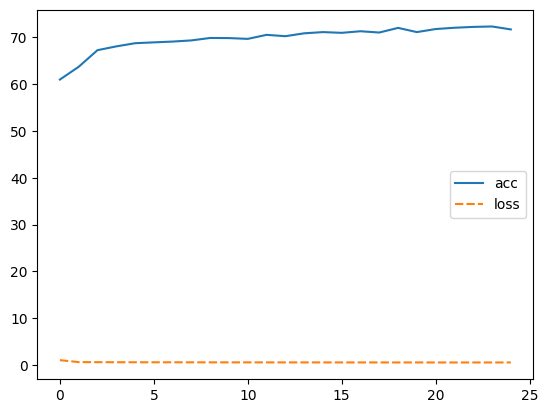

In [63]:
import seaborn as sns

history_df = pd.DataFrame(history.history)
history_df['acc'] = history_df['acc'] * 100
sns.lineplot(data=history_df[['acc', 'loss']])

In [64]:
def evaluate_model(model, X_test, y_test):
    from sklearn.metrics import classification_report

    y_pred = model.predict(X_test)
    y_pred = y_pred.argmax(axis=1)
    y_true = y_test.argmax(axis=1)

    print(classification_report(y_true, y_pred))
    
evaluate_model(model, X_test, y_test)

60/60 [==============================] - 0s 1ms/step
              precision    recall  f1-score   support

           0       0.74      0.70      0.72       961
           1       0.72      0.76      0.74       957

    accuracy                           0.73      1918
   macro avg       0.73      0.73      0.73      1918
weighted avg       0.73      0.73      0.73      1918



My model with dropout and batch normalization for preventing overfitting

In [65]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

save_dir = 'saved_models'
model_name = 'cnn_model.h5'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
model_path = os.path.join(save_dir, model_name)

checkpoint = ModelCheckpoint(
    filepath=model_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

def build_model(input_shape, num_classes):
    input_layer = Input(shape=input_shape, name='input')

    conv1 = Conv1D(64, kernel_size=(3,), activation='relu', kernel_regularizer=l2(0.01), name='conv1')(input_layer)
    bn1 = BatchNormalization()(conv1)
    drop1 = Dropout(0.5)(bn1)
    conv2 = Conv1D(128, kernel_size=(3,), activation='relu', kernel_regularizer=l2(0.01), name='conv2')(drop1)
    bn2 = BatchNormalization()(conv2)
    drop2 = Dropout(0.5)(bn2)
    pool1 = MaxPooling1D(pool_size=(2,), name='pool1')(drop2)
    conv3 = Conv1D(256, kernel_size=(3,), activation='relu', kernel_regularizer=l2(0.01), name='conv3')(pool1)
    bn3 = BatchNormalization()(conv3)
    drop3 = Dropout(0.5)(bn3)
    pool2 = MaxPooling1D(pool_size=(2,), name='pool2')(drop3)
    flatten = Flatten(name='flatten')(pool2)
    dense1 = Dense(256, activation='relu', kernel_regularizer=l2(0.01), name='dense')(flatten)
    bn4 = BatchNormalization()(dense1)
    drop4 = Dropout(0.5)(bn4)
    output_layer = Dense(num_classes, activation='softmax', name='output')(drop4)

    model = Model(input_layer, output_layer, name='static_model')
    model.compile(
        loss=CategoricalCrossentropy(),
        optimizer = Adam(learning_rate=0.001),
        metrics=[CategoricalAccuracy(name="acc")],
    )

    return model

input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2])
num_classes = y_train.shape[1]
model = build_model(input_shape, num_classes)
model.summary()

Model: "static_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 26, 1)]           0         
                                                                 
 conv1 (Conv1D)              (None, 24, 64)            256       
                                                                 
 batch_normalization_4 (Bat  (None, 24, 64)            256       
 chNormalization)                                                
                                                                 
 dropout_6 (Dropout)         (None, 24, 64)            0         
                                                                 
 conv2 (Conv1D)              (None, 22, 128)           24704     
                                                                 
 batch_normalization_5 (Bat  (None, 22, 128)           512       
 chNormalization)                                     

In [66]:
from tensorflow.keras.callbacks import LearningRateScheduler
from sklearn.utils.class_weight import compute_class_weight

def lr_schedule(epoch, lr):
    if epoch > 10:
        lr = lr * 0.1
    return lr

lr_scheduler = LearningRateScheduler(lr_schedule)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(np.argmax(y_train, axis=1)),
    y=np.argmax(y_train, axis=1)
)

class_weights = {i: class_weights[i] for i in range(len(class_weights))}


history = model.fit(
    X_train_reshaped, y_train,
    epochs=100,
    batch_size=32,
    verbose=1,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stopping, checkpoint, lr_scheduler]
)

Epoch 1/100
192/192 [==============================] - ETA: 0s - loss: 6.0117 - acc: 0.5396
Epoch 1: val_loss improved from inf to 4.70245, saving model to saved_models\cnn_model.h5
192/192 [==============================] - 4s 11ms/step - loss: 6.0117 - acc: 0.5396 - val_loss: 4.7025 - val_acc: 0.5254 - lr: 0.0010
Epoch 2/100
 13/192 [=>............................] - ETA: 1s - loss: 4.7083 - acc: 0.5481

c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


187/192 [============================>.] - ETA: 0s - loss: 3.9349 - acc: 0.5647
Epoch 2: val_loss improved from 4.70245 to 3.16482, saving model to saved_models\cnn_model.h5
192/192 [==============================] - 2s 10ms/step - loss: 3.9173 - acc: 0.5645 - val_loss: 3.1648 - val_acc: 0.5463 - lr: 0.0010
Epoch 3/100
189/192 [============================>.] - ETA: 0s - loss: 2.7102 - acc: 0.5673
Epoch 3: val_loss improved from 3.16482 to 2.23538, saving model to saved_models\cnn_model.h5
192/192 [==============================] - 2s 10ms/step - loss: 2.7039 - acc: 0.5673 - val_loss: 2.2354 - val_acc: 0.5815 - lr: 0.0010
Epoch 4/100
190/192 [============================>.] - ETA: 0s - loss: 1.9281 - acc: 0.5793
Epoch 4: val_loss improved from 2.23538 to 1.63541, saving model to saved_models\cnn_model.h5
192/192 [==============================] - 2s 10ms/step - loss: 1.9256 - acc: 0.5799 - val_loss: 1.6354 - val_acc: 0.6108 - lr: 0.0010
Epoch 5/100
187/192 [============================

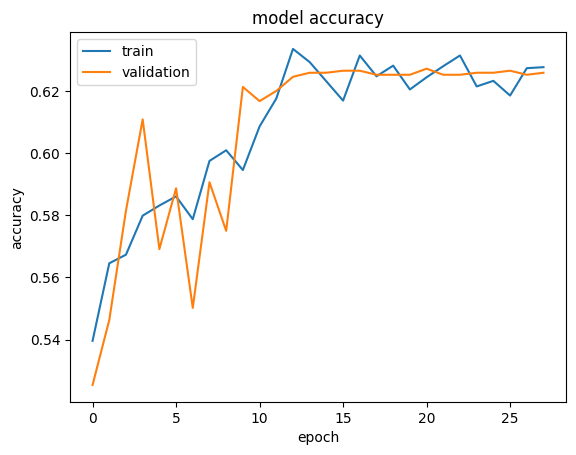

In [67]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

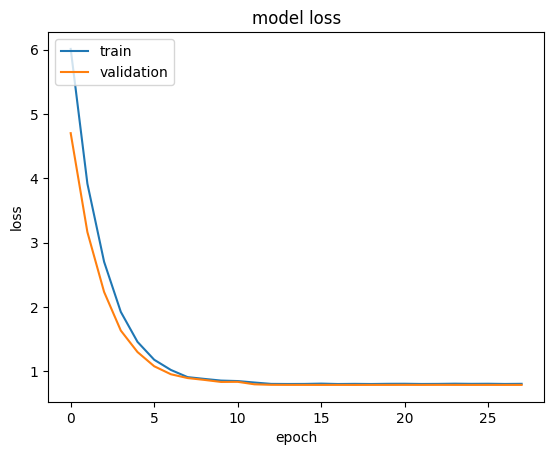

In [68]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [69]:
def evaluate_model(model, X_test, y_test):
    from sklearn.metrics import classification_report

    y_pred = model.predict(X_test)
    y_pred = y_pred.argmax(axis=1)
    y_true = y_test.argmax(axis=1)

    print(classification_report(y_true, y_pred))
    
evaluate_model(model, X_test, y_test)

60/60 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0       0.67      0.54      0.60       961
           1       0.61      0.73      0.67       957

    accuracy                           0.63      1918
   macro avg       0.64      0.63      0.63      1918
weighted avg       0.64      0.63      0.63      1918



Feature Importance using Random Forest

Feature ranking:
1. feature 23 (0.225829)
2. feature 25 (0.162073)
3. feature 24 (0.161775)
4. feature 2 (0.095742)
5. feature 4 (0.077236)
6. feature 18 (0.069059)
7. feature 8 (0.044234)
8. feature 6 (0.035476)
9. feature 0 (0.030164)
10. feature 16 (0.023970)
11. feature 7 (0.019996)
12. feature 5 (0.013732)
13. feature 9 (0.010387)
14. feature 19 (0.005522)
15. feature 14 (0.004907)
16. feature 15 (0.004346)
17. feature 22 (0.002970)
18. feature 20 (0.002810)
19. feature 17 (0.002556)
20. feature 21 (0.001711)
21. feature 13 (0.001463)
22. feature 11 (0.001317)
23. feature 10 (0.001095)
24. feature 3 (0.000926)
25. feature 1 (0.000701)
26. feature 12 (0.000000)


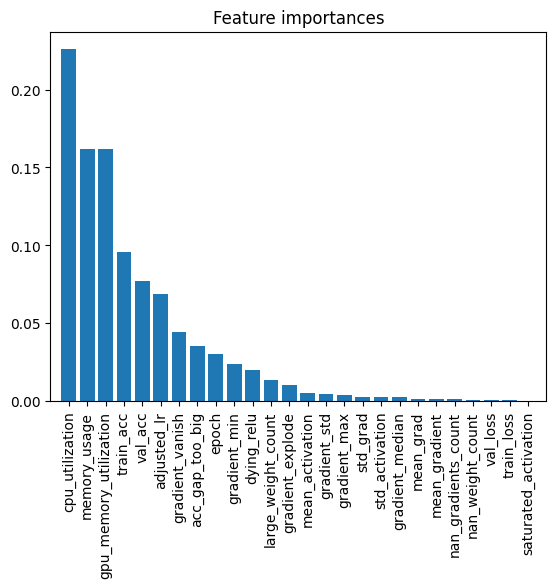

In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
importances = clf.feature_importances_

indices = np.argsort(importances)[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]
plt.figure()
plt.title("Feature importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

In [71]:
# Select features with importance greater than the mean importance
sfm = SelectFromModel(clf, threshold="mean")
sfm.fit(X_train, y_train)
X_important_train = sfm.transform(X_train)
X_important_test = sfm.transform(X_test)

print("Number of features before selection: ", X_train.shape[1])
print("Number of features after selection: ", X_important_train.shape[1])

Number of features before selection:  26
Number of features after selection:  7


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 7)]               0         
                                                                 
 dense_3 (Dense)             (None, 64)                512       
                                                                 
 dropout_10 (Dropout)        (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dropout_11 (Dropout)        (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 2)                 66        
                                                                 
Total params: 2658 (10.38 KB)
Trainable params: 2658 (10.38

c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


165/192 [========================>.....] - ETA: 0s - loss: 0.6702 - categorical_accuracy: 0.5670
Epoch 2: val_categorical_accuracy improved from 0.57757 to 0.58670, saving model to best_model.h5
192/192 [==============================] - 0s 2ms/step - loss: 0.6702 - categorical_accuracy: 0.5647 - val_loss: 0.6493 - val_categorical_accuracy: 0.5867
Epoch 3/100
190/192 [============================>.] - ETA: 0s - loss: 0.6543 - categorical_accuracy: 0.5900
Epoch 3: val_categorical_accuracy improved from 0.58670 to 0.61017, saving model to best_model.h5
192/192 [==============================] - 0s 2ms/step - loss: 0.6545 - categorical_accuracy: 0.5898 - val_loss: 0.6426 - val_categorical_accuracy: 0.6102
Epoch 4/100
160/192 [========================>.....] - ETA: 0s - loss: 0.6359 - categorical_accuracy: 0.6162
Epoch 4: val_categorical_accuracy did not improve from 0.61017
192/192 [==============================] - 0s 2ms/step - loss: 0.6374 - categorical_accuracy: 0.6113 - val_loss: 0.6

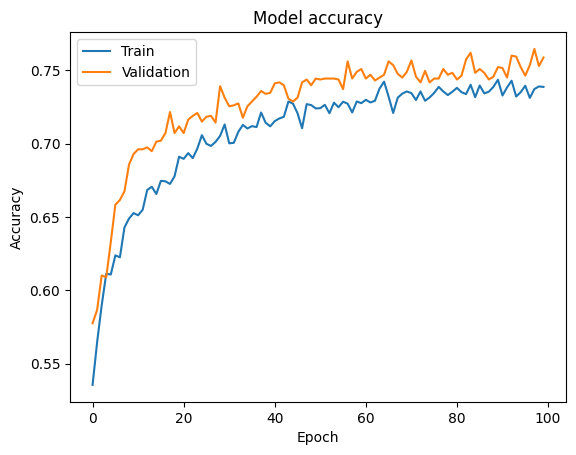

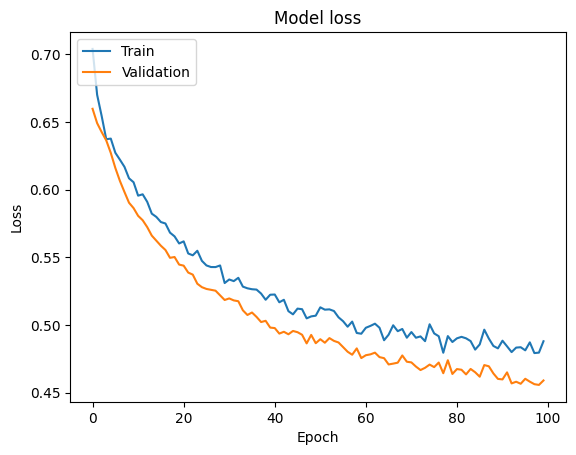

In [72]:
# simple NN model with feature selection
input_layer = Input(shape=(X_important_train.shape[1],))
layer = Dense(64, activation='relu')(input_layer)
layer = Dropout(0.5)(layer)
layer = Dense(32, activation='relu')(layer)
layer = Dropout(0.5)(layer)
output_layer = Dense(2, activation='softmax')(layer)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.001), loss=CategoricalCrossentropy(), metrics=[CategoricalAccuracy()])
model.summary()

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=20)
mc = ModelCheckpoint('best_model.h5', monitor='val_categorical_accuracy', mode='max', verbose=1, save_best_only=True)

history = model.fit(X_important_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[es, mc])
model.load_weights('best_model.h5')
y_pred = model.predict(X_important_test)
y_pred = np.argmax(y_pred, axis=1)
y_test = np.argmax(y_test, axis=1)
print(classification_report(y_test, y_pred, target_names=encoder.categories_[0]))

plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Feature importance 

Feature ranking:
1. feature 23 (0.225829)
2. feature 25 (0.162073)
3. feature 24 (0.161775)
4. feature 2 (0.095742)
5. feature 4 (0.077236)
6. feature 18 (0.069059)
7. feature 8 (0.044234)
8. feature 6 (0.035476)
9. feature 0 (0.030164)
10. feature 16 (0.023970)
11. feature 7 (0.019996)
12. feature 5 (0.013732)
13. feature 9 (0.010387)
14. feature 19 (0.005522)
15. feature 14 (0.004907)
16. feature 15 (0.004346)
17. feature 22 (0.002970)
18. feature 20 (0.002810)
19. feature 17 (0.002556)
20. feature 21 (0.001711)
21. feature 13 (0.001463)
22. feature 11 (0.001317)
23. feature 10 (0.001095)
24. feature 3 (0.000926)
25. feature 1 (0.000701)
26. feature 12 (0.000000)


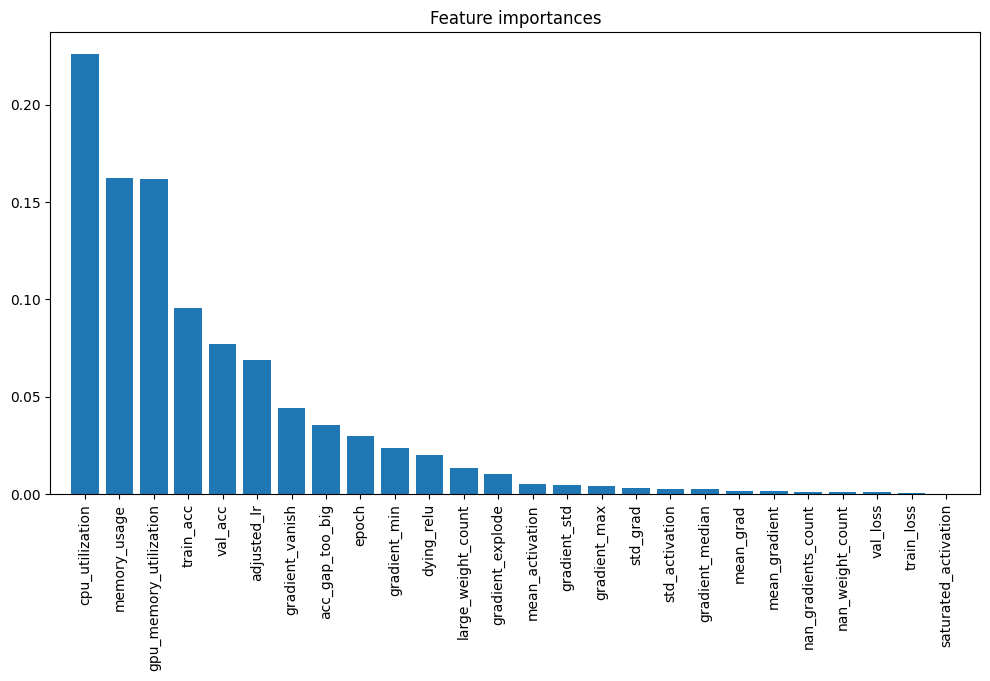

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
importances = clf.feature_importances_

indices = np.argsort(importances)[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))


feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Feature importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

In [74]:
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train = np.argmax(y_train, axis=1)

Feature ranking:
1. feature 23 (0.201408)
2. feature 24 (0.130970)
3. feature 25 (0.122941)
4. feature 18 (0.029875)
5. feature 2 (0.027998)
6. feature 0 (0.025391)
7. feature 8 (0.023410)
8. feature 7 (0.019604)
9. feature 6 (0.016684)
10. feature 4 (0.011679)
11. feature 16 (0.011366)
12. feature 5 (0.003754)
13. feature 9 (0.002346)
14. feature 14 (0.001668)
15. feature 22 (0.000834)
16. feature 20 (0.000469)
17. feature 3 (0.000261)
18. feature 15 (0.000209)
19. feature 1 (0.000104)
20. feature 11 (0.000104)
21. feature 21 (0.000104)
22. feature 13 (0.000104)
23. feature 17 (0.000104)
24. feature 10 (0.000104)
25. feature 12 (0.000000)
26. feature 19 (-0.000521)


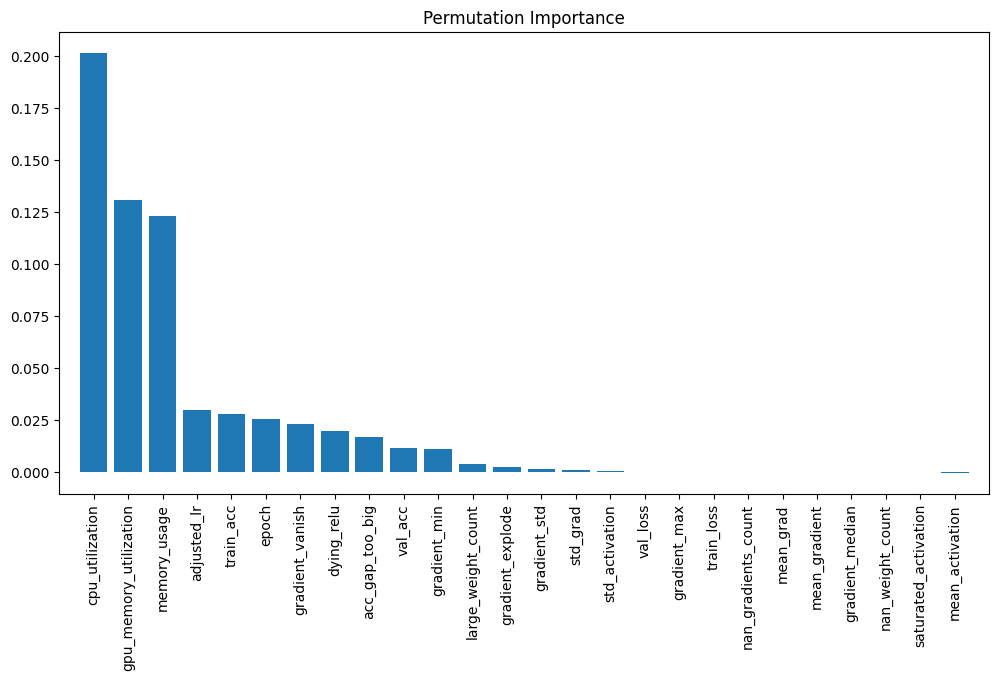

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
indices = result.importances_mean.argsort()[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], result.importances_mean[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Permutation Importance")
plt.bar(range(X_train.shape[1]), result.importances_mean[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()


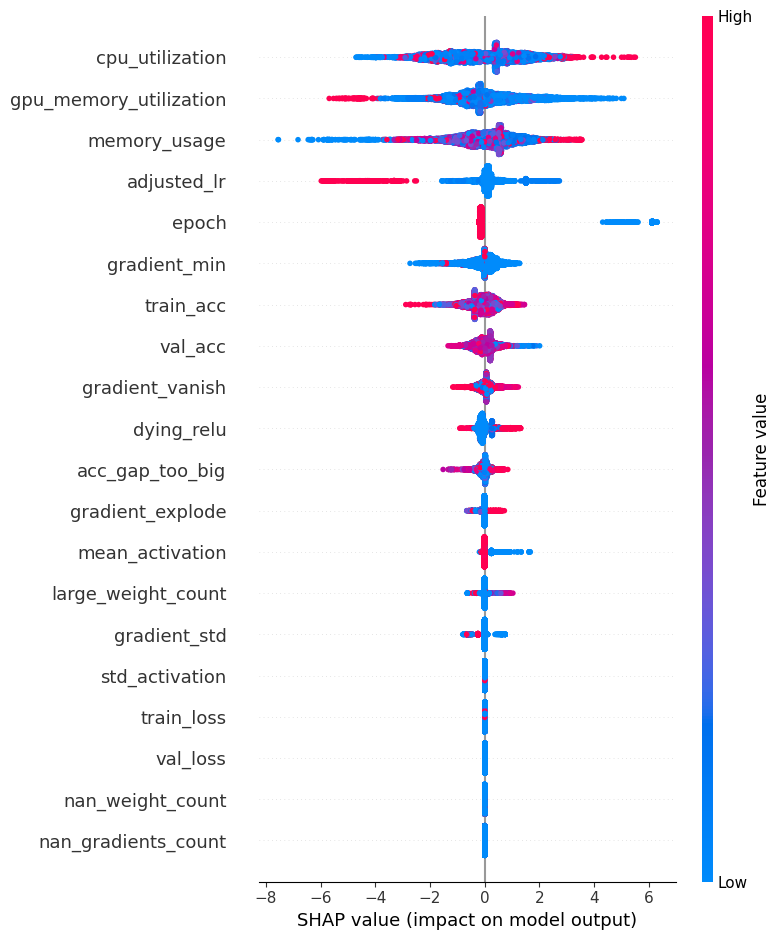

In [76]:
import shap
import xgboost as xgb

model = xgb.XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
feature_names = X.columns
shap.summary_plot(shap_values, X_train, feature_names=feature_names)


Feature ranking:
1. feature 18 (-2.065337)
2. feature 0 (-1.689448)
3. feature 19 (-1.295976)
4. feature 20 (-1.201696)
5. feature 21 (-0.959247)
6. feature 16 (-0.917883)
7. feature 14 (0.812905)
8. feature 5 (0.397933)
9. feature 3 (-0.326598)
10. feature 1 (-0.319729)
11. feature 24 (-0.257736)
12. feature 4 (-0.099649)
13. feature 17 (0.086363)
14. feature 2 (0.080648)
15. feature 23 (0.076031)
16. feature 11 (-0.071844)
17. feature 22 (0.070668)
18. feature 6 (-0.056834)
19. feature 25 (0.056676)
20. feature 7 (0.041931)
21. feature 8 (0.033262)
22. feature 10 (-0.030541)
23. feature 13 (0.018215)
24. feature 15 (0.015960)
25. feature 9 (0.007159)
26. feature 12 (0.000000)


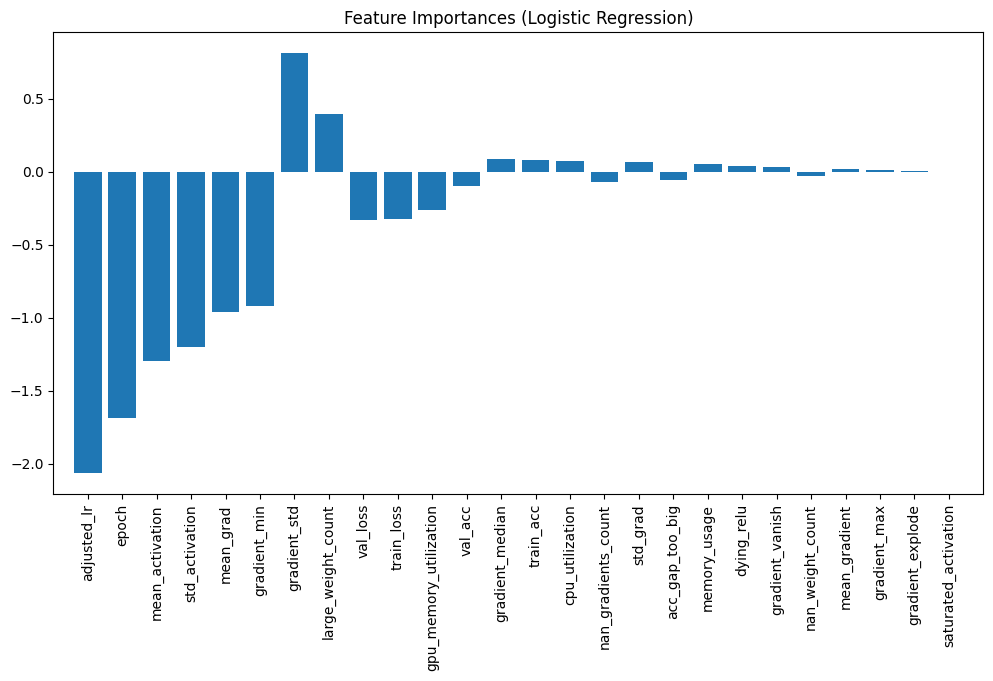

In [77]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
importance = model.coef_[0]
indices = np.argsort(np.abs(importance))[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importance[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Logistic Regression)")
plt.bar(range(X_train.shape[1]), importance[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import shap
import xgboost as xgb
import lime
import lime.lime_tabular
from sklearn.linear_model import LogisticRegression

if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train = np.argmax(y_train, axis=1)

if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)

if isinstance(X_train, np.ndarray):
    X_train = pd.DataFrame(X_train, columns=X.columns)
if isinstance(X_test, np.ndarray):
    X_test = pd.DataFrame(X_test, columns=X.columns)

print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], result.importances_mean[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=['class_0', 'class_1'],  
    mode='classification'
)

i = 0  
exp = explainer.explain_instance(X_test.iloc[i], model.predict_proba, num_features=10)
exp.show_in_notebook(show_all=False)


Feature ranking:
1. feature 18 (0.029875)
2. feature 0 (0.025391)
3. feature 19 (-0.000521)
4. feature 20 (0.000469)
5. feature 21 (0.000104)
6. feature 16 (0.011366)
7. feature 14 (0.001668)
8. feature 5 (0.003754)
9. feature 3 (0.000261)
10. feature 1 (0.000104)
11. feature 24 (0.130970)
12. feature 4 (0.011679)
13. feature 17 (0.000104)
14. feature 2 (0.027998)
15. feature 23 (0.201408)
16. feature 11 (0.000104)
17. feature 22 (0.000834)
18. feature 6 (0.016684)
19. feature 25 (0.122941)
20. feature 7 (0.019604)
21. feature 8 (0.023410)
22. feature 10 (0.000104)
23. feature 13 (0.000104)
24. feature 15 (0.000209)
25. feature 9 (0.002346)
26. feature 12 (0.000000)


c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (co